In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD002.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD003.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/Damage Propagation Modeling.pdf
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/readme.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD003.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD004.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD004.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD002.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD001.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD002.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD001.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD004.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-si

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD002.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD003.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/Damage Propagation Modeling.pdf
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/readme.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD003.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD004.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD004.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD002.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD001.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD002.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD001.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD004.txt
/kaggle/input/datasets/palbha/cmapss-jet-engine-si

In [4]:
import pandas as pd

col_names = ['unit_number', 'time_cycle', 'setting_1', 'setting_2', 'setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

path = '/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD001.txt'
df = pd.read_csv(path, sep=r'\s+', header=None, names=col_names)

print(df.shape)
df.head()

(20631, 26)


,unit_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


****Rul Hesaplama (Her motorun en yüksek çevrimini (yani arızalandığı anı) buluyor, ana tabloyla birleştiriyor, RUL = max_cycle - time_cycle ile "kalan ömrü" hesaplıyor.)****

In [5]:
max_cycle = df.groupby('unit_number')['time_cycle'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

df = df.merge(max_cycle, on='unit_number', how='left')
df['RUL'] = df['max_cycle'] - df['time_cycle']
df.drop('max_cycle', axis=1, inplace=True)

df[['unit_number', 'time_cycle', 'RUL']].head(10)

,unit_number,time_cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


## St sapma hesaplama

****Bu, hangi sensörlerin hiç değişmediğini (standart sapması ~0 olanları) gösterecek.****

In [6]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = df[sensor_cols].std()
print(sensor_std.sort_values())

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


****Neler Yaptık?
Hiç değişmeyen (sabit) 8 sensör/setting sütununu veriden çıkardık — bilgi taşımadıkları için
Kalan 14 sensörün her biri için 2 yeni özellik türettik:
roll_mean: son 5 çevrimin ortalaması (trend bilgisi)
roll_std: son 5 çevrimin ne kadar dalgalandığı (istikrarsızlık bilgisi)
Hesaplanamayan (ilk satırlardaki) boş değerleri 0 ile doldurduk****

In [7]:
cols_to_drop = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 
                 'sensor_16', 'sensor_18', 'sensor_19', 'setting_3']
df_clean = df.drop(columns=cols_to_drop)

sensor_cols_clean = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 
                      'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
                      'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

window = 5
for col in sensor_cols_clean:
    df_clean[f'{col}_roll_mean'] = df_clean.groupby('unit_number')[col].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    ) #O motorun, o çevrime kadar olan son 5 çevrimin ortalama sensör değeri roll mean
    df_clean[f'{col}_roll_std'] = df_clean.groupby('unit_number')[col].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    ) #Aynı 5 çevrimlik pencerede sensörün ne kadar dalgalandığı roll std

df_clean.fillna(0, inplace=True)

print("Yeni boyut:", df_clean.shape)
df_clean.head()

Yeni boyut: (20631, 47)


,unit_number,time_cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,...,sensor_14_roll_mean,sensor_14_roll_std,sensor_15_roll_mean,sensor_15_roll_std,sensor_17_roll_mean,sensor_17_roll_std,sensor_20_roll_mean,sensor_20_roll_std,sensor_21_roll_mean,sensor_21_roll_std
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,...,8138.620000,0.000000,8.419500,0.000000,392.000000,0.000000,39.060000,0.000000,23.419000,0.000000
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


****100 ağaçtan oluşan bir model kuruyoruz
MAE: Model ort kaç çevrim yanılıyor
R² → model gerçek RUL(kalan kullanım ömrü) değişiminin yüzde kaçını açıklayabiliyor****

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Motorları train ve test olarak ayır (satır değil, motor bazlı - veri sızıntısını önlemek için)
unit_ids = df_clean['unit_number'].unique()
train_units, test_units = train_test_split(unit_ids, test_size=0.2, random_state=42)

train_df = df_clean[df_clean['unit_number'].isin(train_units)]
test_df = df_clean[df_clean['unit_number'].isin(test_units)]

feature_cols = [c for c in df_clean.columns if c not in ['unit_number', 'time_cycle', 'RUL']]

X_train, y_train = train_df[feature_cols], train_df['RUL']
X_test, y_test = test_df[feature_cols], test_df['RUL']

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 24.25813759213759
R²: 0.730665517776543


## Model iyileştirme RUL CAPPİNG

In [9]:
# RUL'u 125 ile sınırla
df_clean['RUL_clipped'] = df_clean['RUL'].clip(upper=125)

# Aynı train/test bölünmesini kullan
train_df = df_clean[df_clean['unit_number'].isin(train_units)]
test_df = df_clean[df_clean['unit_number'].isin(test_units)]

y_train_clipped = train_df['RUL_clipped']
y_test_clipped = test_df['RUL_clipped']

model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train_clipped)

y_pred2 = model2.predict(X_test)
print("MAE (clipped):", mean_absolute_error(y_test_clipped, y_pred2))
print("R² (clipped):", r2_score(y_test_clipped, y_pred2))

MAE (clipped): 11.777727272727272
R² (clipped): 0.8409015216821865


> Şu Anki Durum

Projenin bu noktaya kadarki tüm adımları başarıyla tamamlandı:

✅ Veri yüklendi
✅ RUL hesaplandı
✅ Sabit sensörler temizlendi
✅ Feature engineering (rolling stats) yapıldı
✅ Model kuruldu (MAE 24.26, R² 0.73)
✅ RUL capping ile iyileştirildi (MAE 11.78, R² 0.84)

## Model Yorumlama

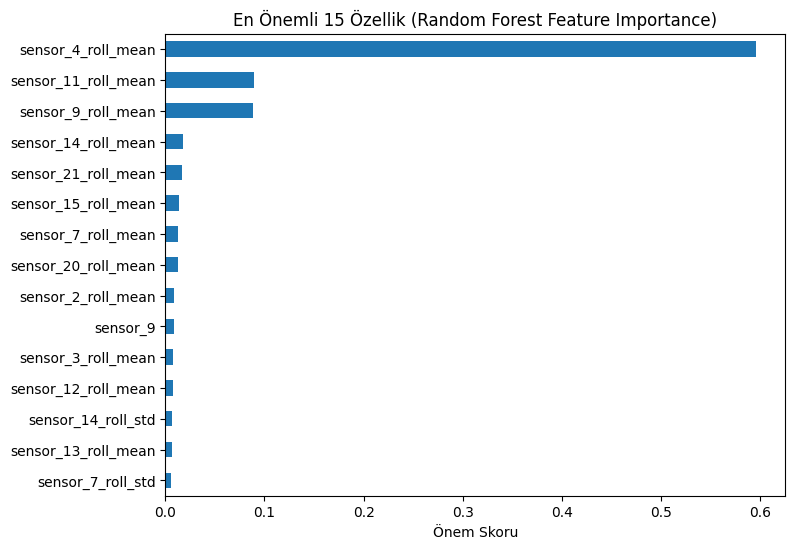

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model2.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("En Önemli 15 Özellik (Random Forest Feature Importance)")
plt.xlabel("Önem Skoru")
plt.show()

## Hangi değişkene karşılık geliyor onu görüyoruz.

In [11]:
with open('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/readme.txt', 'r', encoding='latin-1') as f:
    print(f.read())

Data Set: FD001
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: ONE (HPC Degradation)

Data Set: FD002
Train trjectories: 260
Test trajectories: 259
Conditions: SIX 
Fault Modes: ONE (HPC Degradation)

Data Set: FD003
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: TWO (HPC Degradation, Fan Degradation)

Data Set: FD004
Train trjectories: 248
Test trajectories: 249
Conditions: SIX 
Fault Modes: TWO (HPC Degradation, Fan Degradation)



Experimental Scenario

Data sets consists of multiple multivariate time series. Each data set is further divided into training and test subsets. Each time series is from a different engine  i.e., the data can be considered to be from a fleet of engines of the same type. Each engine starts with different degrees of initial wear and manufacturing variation which is unknown to the user. This wear and variation is considered normal, i.e., it is not considered a fault condition. Th

## Sonuçlar ve Yorumlama

Bu projede NASA CMAPSS Turbofan Jet Engine dataseti (FD001 alt-kümesi) kullanılarak, 
uçak motorlarının kalan kullanım ömrünü (RUL - Remaining Useful Life) tahmin eden bir 
Random Forest regresyon modeli geliştirilmiştir.

**Yöntem:**
- 100 motorun sensör verisi üzerinde feature engineering (rolling mean/std, 5 çevrimlik pencere)
- RUL capping (üst sınır 125) ile modelin arızaya yakın bölgeye odaklanması sağlandı
- Motor bazlı train/test ayrımı ile veri sızıntısı önlendi

**Sonuç:**
- MAE: 11.78 çevrim
- R²: 0.84

**En Belirleyici Sensörler:**
Model tahminini büyük ölçüde `sensor_4` (T50 - Düşük Basınç Türbini sıcaklığı) trendine 
dayandırıyor; `sensor_9` (Nc - çekirdek dönüş hızı) ve `sensor_11` (Ps30 - Yüksek Basınç 
Kompresörü çıkış basıncı) destekleyici rol oynuyor. Bu, dataset'in tek arıza modu olan 
HPC Degradation (kompresör bozulması) ile fiziksel olarak tutarlı: kompresör bozuldukça 
motorun termodinamik dengesi bu sensörlerde görünür şekilde kayıyor.

*Kaynak: Sensör tanımları için Saxena vd. (2008) CMAPSS dokümantasyonu referans alınmıştır.*

---
# Proje 2: Anomaly Detection (Isolation Forest)

Amaç: Etiketli RUL verisi olmadan, sadece sensör verisine bakarak "normal dışı" 
motor davranışını tespit eden bir model kurmak.

In [12]:
from sklearn.ensemble import IsolationForest

# Aynı sensör + rolling feature'ları kullanıyoruz (RUL hariç, çünkü bu unsupervised)
anomaly_features = [c for c in df_clean.columns if c not in ['unit_number', 'time_cycle', 'RUL', 'RUL_clipped']]

iso_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
df_clean['anomaly_score'] = iso_model.fit_predict(df_clean[anomaly_features])

# -1 = anomali, 1 = normal
print(df_clean['anomaly_score'].value_counts())

anomaly_score
 1    19599
-1     1032
Name: count, dtype: int64


## Anomali Sonuçlarını Görselleştir

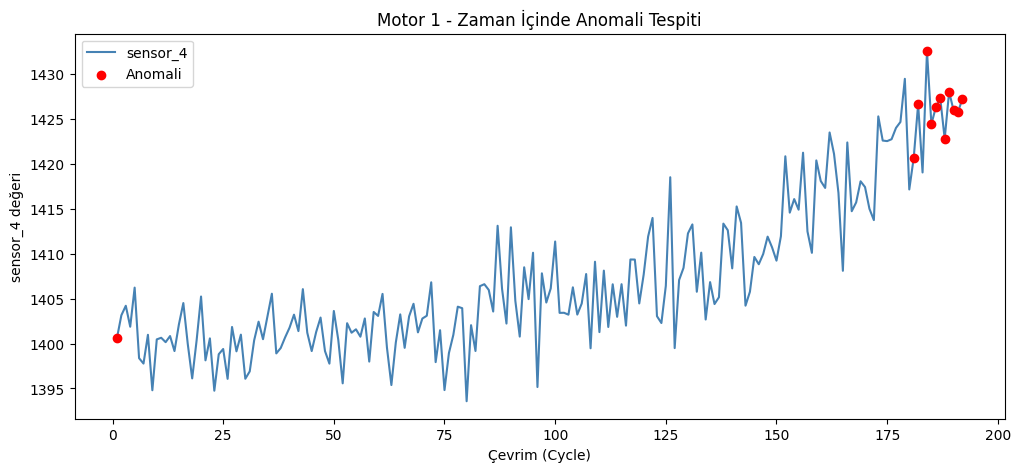

In [14]:
import matplotlib.pyplot as plt

# Örnek olarak tek bir motoru (unit_number=1) seçip zaman içinde anomali noktalarını görelim
engine_1 = df_clean[df_clean['unit_number'] == 1].copy()

plt.figure(figsize=(12, 5))
plt.plot(engine_1['time_cycle'], engine_1['sensor_4'], label='sensor_4', color='steelblue')

anomalies = engine_1[engine_1['anomaly_score'] == -1]
plt.scatter(anomalies['time_cycle'], anomalies['sensor_4'], color='red', label='Anomali', zorder=5)

plt.xlabel('Çevrim (Cycle)')
plt.ylabel('sensor_4 değeri')
plt.title('Motor 1 - Zaman İçinde Anomali Tespiti')
plt.legend()
plt.show()

## Anomalilerin RUL ile İlişkisini Doğrula

In [15]:
# Anomali olarak işaretlenen satırların ortalama RUL'u
anomaly_rul = df_clean[df_clean['anomaly_score'] == -1]['RUL'].mean()
normal_rul = df_clean[df_clean['anomaly_score'] == 1]['RUL'].mean()

print(f"Anomali işaretli satırların ortalama RUL'u: {anomaly_rul:.1f}")
print(f"Normal işaretli satırların ortalama RUL'u: {normal_rul:.1f}")

Anomali işaretli satırların ortalama RUL'u: 25.3
Normal işaretli satırların ortalama RUL'u: 112.2


## Kaç Çevrim Önceden Uyarı Verdiğini Ölç

In [16]:
# Her motor için ilk anomali işaretinin geldiği RUL değeri (yani ne kadar erken uyarı verdi)
first_anomaly_rul = df_clean[df_clean['anomaly_score'] == -1].groupby('unit_number')['RUL'].max()

print("Motor başına, ilk anomali sinyalinin geldiği RUL (kalan çevrim):")
print(first_anomaly_rul.describe())

Motor başına, ilk anomali sinyalinin geldiği RUL (kalan çevrim):
count    100.000000
mean     196.830000
std       62.812219
min        8.000000
25%      168.500000
50%      197.500000
75%      228.250000
max      361.000000
Name: RUL, dtype: float64


In [17]:
# Anomali işaretlenen satırların time_cycle dağılımına bakalım
anomaly_cycles = df_clean[df_clean['anomaly_score'] == -1]['time_cycle']
print(anomaly_cycles.describe())

# İlk 5 çevrimde kaç anomali var?
print("\nİlk 5 çevrimdeki anomali sayısı:", (anomaly_cycles <= 5).sum())

count    1032.000000
mean      185.848837
std        75.197254
min         1.000000
25%       166.750000
50%       193.000000
75%       217.250000
max       362.000000
Name: time_cycle, dtype: float64

İlk 5 çevrimdeki anomali sayısı: 98


In [18]:
# Rolling window'un henüz dolmadığı ilk 5 çevrimi analiz dışı bırak
df_analysis = df_clean[df_clean['time_cycle'] > 5].copy()

anomaly_features = [c for c in df_analysis.columns if c not in ['unit_number', 'time_cycle', 'RUL', 'RUL_clipped', 'anomaly_score']]

iso_model2 = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
df_analysis['anomaly_score'] = iso_model2.fit_predict(df_analysis[anomaly_features])

print(df_analysis['anomaly_score'].value_counts())

# Kontrol: ortalama RUL karşılaştırması
anomaly_rul2 = df_analysis[df_analysis['anomaly_score'] == -1]['RUL'].mean()
normal_rul2 = df_analysis[df_analysis['anomaly_score'] == 1]['RUL'].mean()
print(f"\nAnomali ortalama RUL: {anomaly_rul2:.1f}")
print(f"Normal ortalama RUL: {normal_rul2:.1f}")

# Motor başına ilk anomali RUL'u
first_anomaly_rul2 = df_analysis[df_analysis['anomaly_score'] == -1].groupby('unit_number')['RUL'].max()
print("\nMotor başına ilk anomali sinyali (RUL):")
print(first_anomaly_rul2.describe())

anomaly_score
 1    19124
-1     1007
Name: count, dtype: int64

Anomali ortalama RUL: 10.1
Normal ortalama RUL: 110.5

Motor başına ilk anomali sinyali (RUL):
count    100.000000
mean      32.660000
std       61.667604
min        1.000000
25%        8.000000
50%       12.000000
75%       17.000000
max      269.000000
Name: RUL, dtype: float64


## Proje 2 Sonuçları

Isolation Forest modeli, etiketli veri kullanılmadan (unsupervised), sensör 
verilerindeki anormal davranışları tespit etmek için eğitilmiştir. Rolling window'un 
henüz dolmadığı ilk 5 çevrim, yapay olarak anomali görünmesini önlemek için analiz 
dışı bırakılmıştır.

**Bulgular:**
- Anomali işaretlenen satırların ortalama RUL'u 10.1 çevrim, normal satırların ise 
  110.5 çevrim — model gerçekten arızaya yakın dönemleri güçlü şekilde ayırt edebiliyor.
- Motorların yarısında (medyan), ilk anomali sinyali arızadan 12 çevrim önce geliyor; 
  %75'inde bu süre 17 çevrim veya daha az.
- Bir kısım motorda (dağılımın kuyruğunda) çok daha erken sinyaller görülüyor — bu, 
  operasyonel ayar farklılıklarından kaynaklanabilir ve ileride incelenebilir.

**Anlamı:** Gerçek RUL etiketi olmadan bile, sadece sensör davranışına bakarak 
motorların arızaya yaklaştığını önceden (ortalama 12 çevrim, yaklaşık %6 kalan ömür 
ile) tespit edebilen bir erken uyarı sistemi kurulabiliyor.